Reading: F:\Incidence Map Meghne\RiverMask_1996_2026.geojson
CRS: EPSG:32646
Year field: FID  |  8 yearly masks: ['1990', '1996', '2001', '2005', '2010', '2015', '2019', '2026']
Grid: 2055 x 2137 cells @ 10.0 units
Saved: F:\Incidence Map Meghne\channel_incidence_map.png


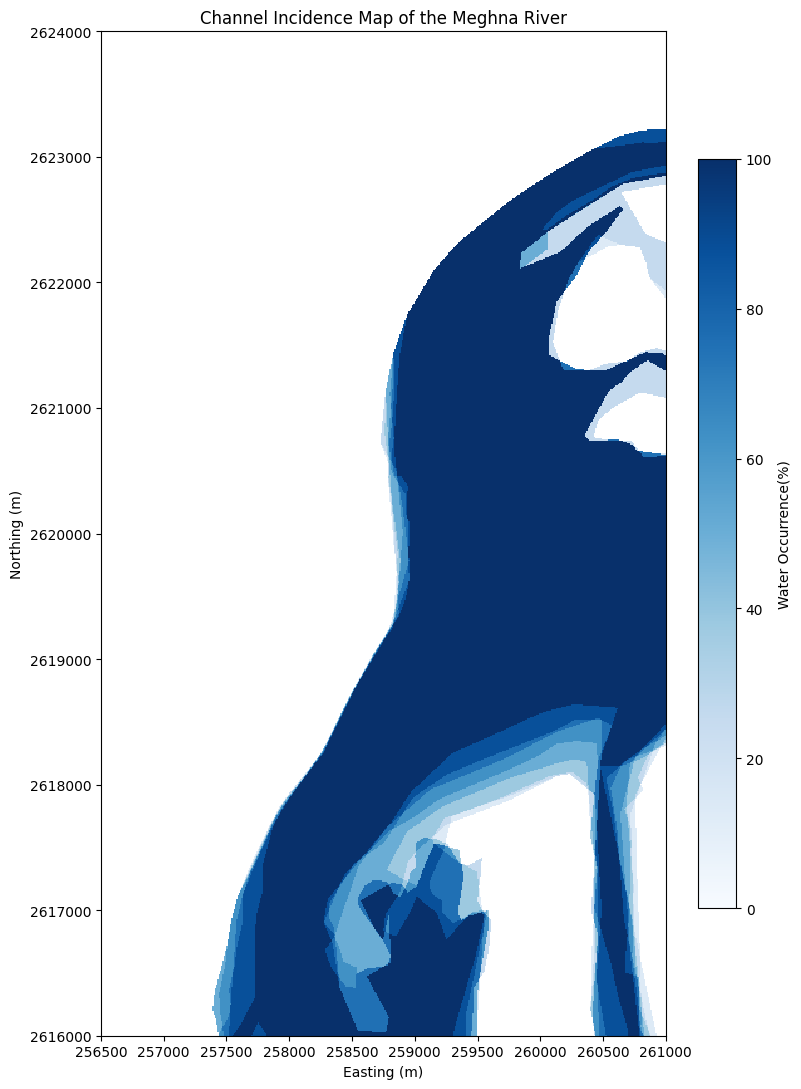

In [8]:
"""
Channel Incidence Frequency Map  (continuous colour bar)
========================================================

Reads a single GeoJSON containing several polygon features (one river mask per
year) and produces a channel incidence frequency map: for every cell, the
percentage of years that the river channel occupied that cell.

Each year's polygon is rasterised as a FILLED interior (not an outline).
The colour bar is a smooth continuous gradient from 0 to 100 %.

HOW TO RUN
----------
Set INPUT_PATH below and run the file (script, notebook, or VS Code Run button).

Requirements (run once in the terminal):
    pip install geopandas rasterio shapely matplotlib
"""

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from rasterio.features import rasterize
from rasterio.transform import from_origin

# ----------------------------------------------------------------------
# Configuration  --  EDIT THESE
# ----------------------------------------------------------------------
INPUT_PATH = r"F:\Incidence Map Meghne\RiverMask_1996_2026.geojson"
OUTPUT_PATH = r"F:\Incidence Map Meghne\channel_incidence_map.png"

CELL_SIZE = 10.0          # raster resolution in CRS units (metres for UTM)
YEAR_FIELD = "FID"         # set to a column name (e.g. "year"); None = auto-detect
TITLE = "Channel Incidence Map of the Meghna River"


def detect_year_field(gdf):
    """Find the attribute that holds the year of each feature."""
    if YEAR_FIELD and YEAR_FIELD in gdf.columns:
        return YEAR_FIELD
    for c in gdf.columns:                       # a column literally named "year"
        if c.lower() == "year":
            return c
    for c in gdf.columns:                       # pull 4-digit year from text field
        if gdf[c].dtype == object:
            years = gdf[c].astype(str).str.extract(r"(\b(?:19|20)\d{2}\b)")[0]
            if years.notna().any():
                gdf["_year"] = years
                return "_year"
    gdf["_year"] = np.arange(len(gdf)).astype(str)   # fall back: one mask/feature
    return "_year"


def main(in_path, out_path):
    print(f"Reading: {in_path}")
    gdf = gpd.read_file(in_path)
    if gdf.crs is None:
        print("Warning: no CRS found; axes will be in raw coordinates.")
    else:
        print(f"CRS: {gdf.crs}")

    year_field = detect_year_field(gdf)
    gdf = gdf.dissolve(by=year_field, as_index=False)   # one mask per year
    n_years = len(gdf)
    print(f"Year field: {year_field}  |  {n_years} yearly masks: "
          f"{sorted(gdf[year_field].astype(str).tolist())}")

    # Common raster grid covering all features
    minx, miny, maxx, maxy = gdf.total_bounds
    width = int(np.ceil((maxx - minx) / CELL_SIZE))
    height = int(np.ceil((maxy - miny) / CELL_SIZE))
    transform = from_origin(minx, maxy, CELL_SIZE, CELL_SIZE)
    print(f"Grid: {width} x {height} cells @ {CELL_SIZE} units")

    # Accumulate FILLED polygon masks
    count = np.zeros((height, width), dtype=np.float32)
    for geom in gdf.geometry:
        mask = rasterize(
            [(geom, 1)],
            out_shape=(height, width),
            transform=transform,
            fill=0,
            all_touched=True,        # keep narrow channels intact
            dtype=np.uint8,
        )
        count += mask                # filled interior, not boundary

    incidence = 100.0 * count / n_years
    incidence = np.where(incidence == 0, np.nan, incidence)  # blank background

    # ------------------------------------------------------------------
    # Plot  --  continuous colour bar
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(9, 11))
    cmap = plt.get_cmap("Blues").copy()
    cmap.set_bad(alpha=0)                 # NaN (no channel) -> transparent
    norm = Normalize(vmin=0, vmax=100)    # smooth gradient 0..100 %

    im = ax.imshow(
        incidence,
        extent=(minx, maxx, miny, maxy),
        origin="upper",
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
    )
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Water Occurrence(%)")

    ax.set_title(TITLE)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_xlim(256500, 261000)
    ax.set_ylim(2616000, 2624000)
    ax.set_aspect("equal")
    ax.ticklabel_format(style="plain", axis="both")

    fig.tight_layout()
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    print(f"Saved: {out_path}")
    plt.show()


if __name__ == "__main__":
    main(INPUT_PATH, OUTPUT_PATH)

Reading: F:\Incidence Map Meghne\RiverMask_1996_2026.geojson
CRS: EPSG:32646
Year field: FID  |  8 yearly masks: ['1990', '1996', '2001', '2005', '2010', '2015', '2019', '2026']
Grid: 2055 x 2137 cells @ 10.0 units
Saved GeoTIFF: F:\Incidence Map Meghne\channel_incidence_map.tif
Saved PNG: F:\Incidence Map Meghne\channel_incidence_map.png


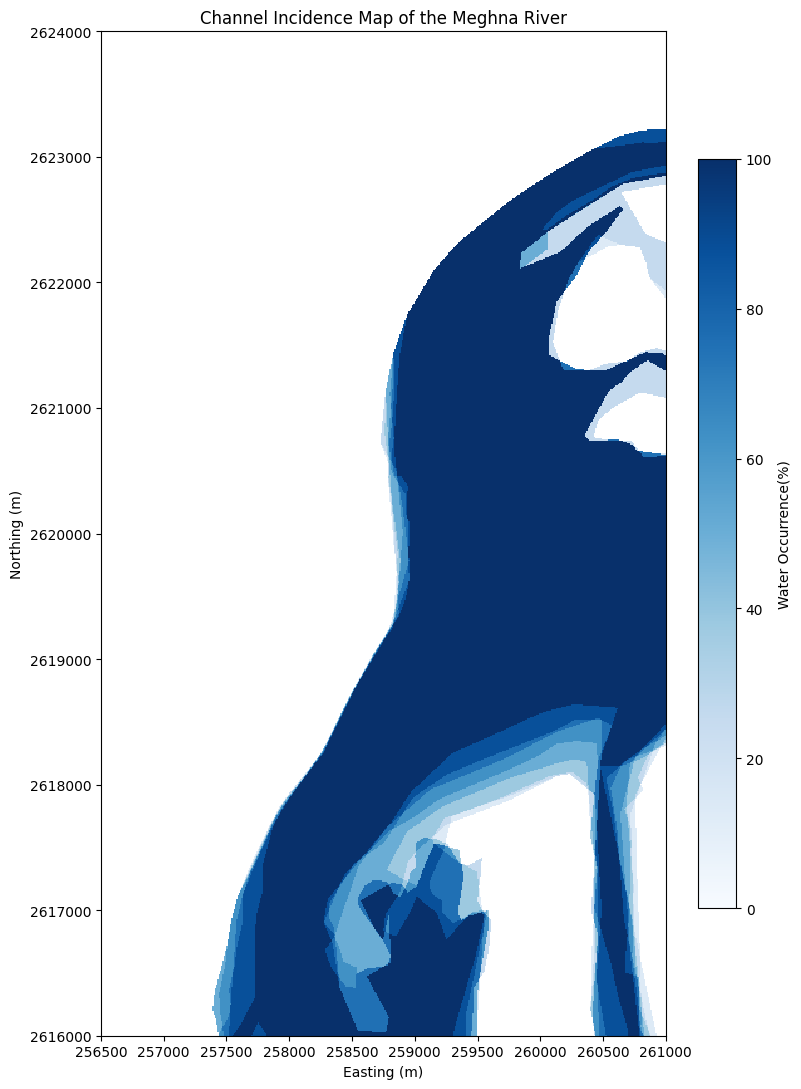

In [9]:
"""
Channel Incidence Frequency Map  (PNG + GeoTIFF export)
=======================================================

Reads a single GeoJSON containing several polygon features (one river mask per
year) and produces a channel incidence frequency map: for every cell, the
percentage of years that the river channel occupied that cell.

Each year's polygon is rasterised as a FILLED interior (not an outline).
Outputs:
  - a PNG figure (continuous colour bar)
  - a GeoTIFF raster (0-100 %, georeferenced, loadable in QGIS)

Requirements (run once in the terminal):
    pip install geopandas rasterio shapely matplotlib
"""

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_origin

# ----------------------------------------------------------------------
# Configuration  --  EDIT THESE
# ----------------------------------------------------------------------
INPUT_PATH = r"F:\Incidence Map Meghne\RiverMask_1996_2026.geojson"
OUTPUT_PATH = r"F:\Incidence Map Meghne\channel_incidence_map.png"
GEOTIFF_PATH = r"F:\Incidence Map Meghne\channel_incidence_map.tif"

CELL_SIZE = 10.0          # raster resolution in CRS units (metres for UTM)
YEAR_FIELD = "FID"        # set to a column name (e.g. "year"); None = auto-detect
TITLE = "Channel Incidence Map of the Meghna River"


def detect_year_field(gdf):
    """Find the attribute that holds the year of each feature."""
    if YEAR_FIELD and YEAR_FIELD in gdf.columns:
        return YEAR_FIELD
    for c in gdf.columns:                       # a column literally named "year"
        if c.lower() == "year":
            return c
    for c in gdf.columns:                       # pull 4-digit year from text field
        if gdf[c].dtype == object:
            years = gdf[c].astype(str).str.extract(r"(\b(?:19|20)\d{2}\b)")[0]
            if years.notna().any():
                gdf["_year"] = years
                return "_year"
    gdf["_year"] = np.arange(len(gdf)).astype(str)   # fall back: one mask/feature
    return "_year"


def main(in_path, out_path, tif_path):
    print(f"Reading: {in_path}")
    gdf = gpd.read_file(in_path)
    if gdf.crs is None:
        print("Warning: no CRS found; GeoTIFF will be written without a CRS.")
    else:
        print(f"CRS: {gdf.crs}")

    year_field = detect_year_field(gdf)
    gdf = gdf.dissolve(by=year_field, as_index=False)   # one mask per year
    n_years = len(gdf)
    print(f"Year field: {year_field}  |  {n_years} yearly masks: "
          f"{sorted(gdf[year_field].astype(str).tolist())}")

    # Common raster grid covering all features
    minx, miny, maxx, maxy = gdf.total_bounds
    width = int(np.ceil((maxx - minx) / CELL_SIZE))
    height = int(np.ceil((maxy - miny) / CELL_SIZE))
    transform = from_origin(minx, maxy, CELL_SIZE, CELL_SIZE)
    print(f"Grid: {width} x {height} cells @ {CELL_SIZE} units")

    # Accumulate FILLED polygon masks
    count = np.zeros((height, width), dtype=np.float32)
    for geom in gdf.geometry:
        mask = rasterize(
            [(geom, 1)],
            out_shape=(height, width),
            transform=transform,
            fill=0,
            all_touched=True,        # keep narrow channels intact
            dtype=np.uint8,
        )
        count += mask                # filled interior, not boundary

    incidence = 100.0 * count / n_years        # 0..100, 0 = never channel

    # ------------------------------------------------------------------
    # Export GeoTIFF  (0 = nodata so empty land is transparent in QGIS)
    # ------------------------------------------------------------------
    with rasterio.open(
        tif_path,
        "w",
        driver="GTiff",
        height=height,
        width=width,
        count=1,
        dtype="float32",
        crs=gdf.crs,
        transform=transform,
        nodata=0,
        compress="lzw",
    ) as dst:
        dst.write(incidence.astype(np.float32), 1)
        dst.set_band_description(1, "Channel incidence frequency (%)")
    print(f"Saved GeoTIFF: {tif_path}")

    # ------------------------------------------------------------------
    # Plot  --  continuous colour bar
    # ------------------------------------------------------------------
    incidence_plot = np.where(incidence == 0, np.nan, incidence)  # blank background
    fig, ax = plt.subplots(figsize=(9, 11))
    cmap = plt.get_cmap("Blues").copy()
    cmap.set_bad(alpha=0)                 # NaN (no channel) -> transparent
    norm = Normalize(vmin=0, vmax=100)    # smooth gradient 0..100 %

    im = ax.imshow(
        incidence_plot,
        extent=(minx, maxx, miny, maxy),
        origin="upper",
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
    )
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Water Occurrence(%)")

    ax.set_title(TITLE)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_xlim(256500, 261000)
    ax.set_ylim(2616000, 2624000)
    ax.set_aspect("equal")
    ax.ticklabel_format(style="plain", axis="both")

    fig.tight_layout()
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    print(f"Saved PNG: {out_path}")
    plt.show()


if __name__ == "__main__":
    main(INPUT_PATH, OUTPUT_PATH, GEOTIFF_PATH)